In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [2]:
# Соберите все данные из папки data в один датафрэйм, имеющий следующие столбцы: колонки из самих файлов (product_id, quantity), а также имя пользователя (name), и дата этих покупок (date), соответствует названию папки, где лежит папка с пользователем)
# Выясните, какой пользователь купил больше всего товаров. Если их несколько, то перечислите имена через запятую с пробелом и в алфавитном порядке.
# Найдите топ-10 товаров по числу проданных единиц за всё время и постройте барплот. Сколько было продано единиц товара с product_id==56?
#  Визуализируйте продажи по дням.
# Сколько пользователей приобрели какой-либо товар повторно (более 1 раза)? Повтором будем считать покупку товара с одинаковым product_id, совершенную в разные дни

In [3]:
p = pd.read_csv('data/2020-12-03/Alexey_Smirnov/data.csv')
p

,Unnamed: 0,product_id,quantity
0,0,47,1
1,1,57,1
2,2,14,2
3,3,52,1
4,4,1,4
5,5,94,4


In [4]:
date = os.listdir('C:/Work/Analytics/data')
date

['2020-12-03',
 '2020-12-04',
 '2020-12-05',
 '2020-12-06',
 '2020-12-07',
 '2020-12-08',
 '2020-12-09']

In [5]:
name = []
for i in date:
    for a in os.listdir(f'C:/Work/Analytics/data/{i}'):
        name.append(a)
name

['Alexey_Smirnov',
 'Anton_Petrov',
 'Kirill_Petrov',
 'Petr_Fedorov',
 'Vasiliy_Ivanov',
 'Vasiliy_Petrov',
 'Alexey_Smirnov',
 'Kirill_Fedorov',
 'Petr_Fedorov',
 'Petr_Ivanov',
 'Petr_Smirnov',
 'Rostislav_Fedorov',
 'Rostislav_Ivanov',
 'Rostislav_Smirnov',
 'Vasiliy_Ivanov',
 'Alexey_Fedorov',
 'Alexey_Petrov',
 'Kirill_Smirnov',
 'Petr_Ivanov',
 'Petr_Smirnov',
 'Rostislav_Smirnov',
 'Vasiliy_Fedorov',
 'Alexey_Fedorov',
 'Alexey_Ivanov',
 'Alexey_Smirnov',
 'Anton_Ivanov',
 'Anton_Smirnov',
 'Kirill_Fedorov',
 'Petr_Fedorov',
 'Petr_Smirnov',
 'Rostislav_Fedorov',
 'Vasiliy_Ivanov',
 'Alexey_Fedorov',
 'Anton_Smirnov',
 'Kirill_Smirnov',
 'Petr_Petrov',
 'Rostislav_Petrov',
 'Alexey_Smirnov',
 'Anton_Ivanov',
 'Anton_Petrov',
 'Anton_Smirnov',
 'Petr_Fedorov',
 'Rostislav_Petrov',
 'Vasiliy_Ivanov']

In [6]:
df = []
for i in date:
    for a in os.listdir(f'C:/Work/Analytics/data/{i}'):
        df_start = pd.read_csv(f'C:/Work/Analytics/data/{i}/{a}/data.csv')
        df_start.insert(loc = 0, column='date', value = i)
        df_start.insert(loc = 1, column='name', value = a)
        df.append(df_start)


df = pd.concat(df)
df = df.reset_index(drop=True)

df.drop(columns='Unnamed: 0', inplace=True)
df

,date,name,product_id,quantity
0,2020-12-03,Alexey_Smirnov,47,1
1,2020-12-03,Alexey_Smirnov,57,1
2,2020-12-03,Alexey_Smirnov,14,2
3,2020-12-03,Alexey_Smirnov,52,1
4,2020-12-03,Alexey_Smirnov,1,4
...,...,...,...,...
156,2020-12-09,Rostislav_Petrov,66,4
157,2020-12-09,Rostislav_Petrov,39,2
158,2020-12-09,Vasiliy_Ivanov,82,4
159,2020-12-09,Vasiliy_Ivanov,74,2


In [7]:
purch_name = df.groupby('name', as_index=False).agg({'quantity': 'sum'}) \
    .sort_values('quantity', ascending=False).head()

# список с макс значением покупок
list(purch_name.query(f'quantity == {df.groupby('name')['quantity'].sum().max()}').name)
#print(purch_name)

['Alexey_Smirnov', 'Petr_Smirnov']

In [8]:
top_10 = df.groupby('product_id', as_index=False).agg({'quantity': 'sum'}) \
    .sort_values('quantity', ascending=False).head(10)
top_10

,product_id,quantity
22,27,20
42,56,18
21,24,15
51,74,15
32,41,14
27,34,13
66,94,13
46,66,13
65,92,12
38,50,12


<Axes: xlabel='product_id', ylabel='quantity'>

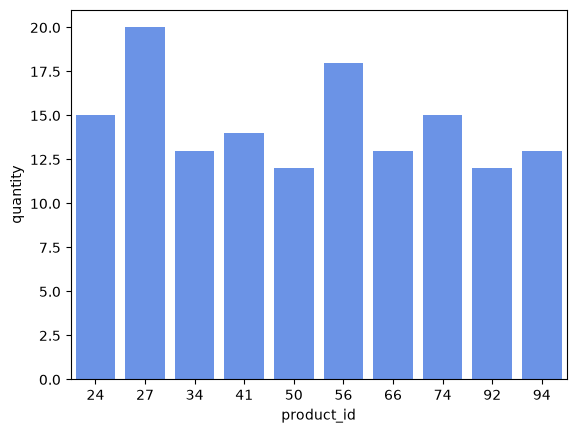

In [9]:
sns.barplot(data=df, x = top_10['product_id'], y = top_10['quantity'])

In [10]:
df_days_quantity = df.groupby('date', as_index = False) \
    .agg({'quantity':'sum'})
df_days_quantity

,date,quantity
0,2020-12-03,60
1,2020-12-04,113
2,2020-12-05,61
3,2020-12-06,15
4,2020-12-07,94
5,2020-12-08,68
6,2020-12-09,69


[Text(0, 0, '60'),
 Text(0, 0, '113'),
 Text(0, 0, '61'),
 Text(0, 0, '15'),
 Text(0, 0, '94'),
 Text(0, 0, '68'),
 Text(0, 0, '69')]

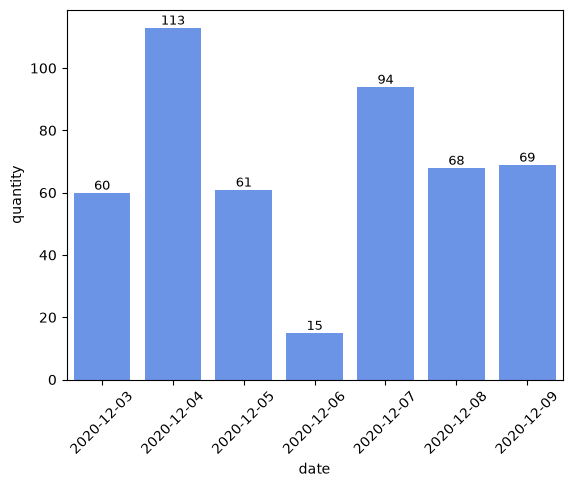

In [11]:
ax = sns.barplot(data=df, x = df_days_quantity['date'], y = df_days_quantity['quantity'])
plt.xticks(rotation=45, fontsize=10)
ax.bar_label(ax.containers[0], fontsize=9)

In [12]:
df_purch_other_days = df.groupby(['name', 'product_id'], as_index=False)['date'].nunique() \
    .query('date > 1')
df_purch_other_days

,name,product_id,date
37,Anton_Ivanov,15,2
92,Petr_Fedorov,94,2


In [13]:
# Доп задание:
#  извлечь из таблицы записи с ИНН, указанными в текстовом файле
#  записать результат в файл selected_inn.csv


In [14]:
inn = '4_necessary_inn.txt'

inn_data = [int(i) for i in open(inn).readlines()]
inn_data

[394609645484,
 281578625230,
 923769811917,
 998694734508,
 271011690615,
 924952812367,
 646685244561,
 581531230312,
 841967395801,
 962179889311,
 873191383820,
 590538076039,
 194319975048,
 614658394086,
 571270160555,
 609400911893,
 595260069852,
 706966142477,
 173050718969,
 968048428696,
 806967744814,
 575198252501,
 283081417246,
 663119569897,
 600958529354,
 280452832937,
 415557497037,
 195142638722,
 472181033836,
 722903871682,
 442387408954,
 196518820495,
 653798670054,
 126259856639,
 175482780898,
 192518356612,
 817648134701,
 321724220657,
 864970037680,
 822991191528,
 205472219644,
 532801459453,
 657038381012,
 197916669463,
 849814898285,
 617082656257,
 500480544925,
 765833725639,
 263518962896,
 415856290529,
 812729265571,
 688172366656,
 837771137752,
 456294893364,
 668157292633,
 491435460276,
 323896131459,
 664667769879,
 293128896936,
 833493884251,
 120708914823,
 860475372268,
 172328288163,
 452188261986,
 818829342640,
 948029225406,
 310163740

In [15]:
inn_excel = pd.read_excel('4_inn.xls')
inn_excel.drop(columns=['Unnamed: 0', '#'], inplace=True)
inn_excel

,name,reg_number,address,head,head_job,head_inn,phone,email,site,registration_date,nalogoplatelschik_code,oktmo_code,okato_code,registration_region,okato_name,field,"capital,RUB","income,RUB"
0,"ЗАО «Власова, Макаров и Шашков»",1143692580560,"д. Кирово-Чепецк, пр. Металлургов, д. 537 к. 3...",Жданов Карл Виленович,Маммолог,109092209811,+7 (559) 338-87-76,bogdanovavtonom@yahoo.com,ooo.info,2015-01-07,2006-10-04,21112877268,73423615032,Ulan-Ude,"к. Тосно, ул. Пушкинская, д. 896, 617222",Синхронизация критически важных отношений,54875526078,32205872896
1,"РАО «Тимофеева, Алексеева и Кузнецова»",9342309660697,"г. Арзамас, наб. Фестивальная, д. 7 стр. 8/2, ...",Рожков Харлампий Алексеевич,Воспитатель,704229465069,8 (632) 620-8879,safonovantonin@rao.org,ooo.net,1990-05-16,2019-01-18,18393547520,19072454279,Tyoply Stan,"ст. Кяхта, бул. Нефтяников, д. 24, 768742",Формирование заказных методик,33876448811,47437574301
2,РАО «Юдин-Ефимова»,1277485323451,"п. Меренга, алл. Достоевского, д. 3/4 к. 497, ...",Филимон Фадеевич Дьячков,Автослесарь,267655036377,+74925330378,kdorofeev@npo.ru,ao.com,1982-11-04,1986-06-19,56104355836,18629292792,Danilov,"клх Усолье Сибирское, алл. Шишкина, д. 3/9 к. ...",Максимизация корпоративных метрик,94073834991,7701710065
3,Доронин Инкорпорэйтед,7139161431511,"д. Иваново, ул. Красных Партизан, д. 83 к. 4, ...",Крылов Глеб Якубович,Тюремный надзиратель,362024991175,+7 118 643 21 48,nkulakova@mail.ru,ooo.ru,2005-01-02,2004-04-06,10398489351,32502585383,Beryozovsky,"г. Заводоуковск, ул. Гражданская, д. 7 к. 8/5,...",Разработка ориентированных на пользователя инт...,86971505490,61148002572
4,Объединенная энергетическая компания,6114798049639,"к. Энгельс, наб. Шишкина, д. 120, 823828",Субботин Вячеслав Федотович,Инженер-электрик,257948948010,8 642 249 2134,evgraf_18@yahoo.com,gerasimova.biz,1983-07-02,1992-06-20,20074507047,40083207999,Bavly,"к. Соль-Илецк, пер. Пригородный, д. 804 к. 1/3...",Монетизация интуитивных веб-сервисов,36351136214,34861533393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2105,"ИП «Зайцев, Шубин и Дементьева»",6580539599719,"к. Чебаркуль, бул. Кольцевой, д. 19 к. 3, 911953",Назар Гордеевич Миронов,Дефектолог,575321775842,8 (390) 976-88-54,juvenali_66@ao.edu,aviakompanija.edu,2007-02-01,2014-10-29,13383530491,62100202894,Gudermes,"г. Миасс, пр. Пожарского, д. 39 стр. 880, 386211",Охват прозрачных методик,88659854892,61232741869
2106,Юдина Лтд,5012825137426,"д. Темрюк, ш. Автомобилистов, д. 9 стр. 59, 80...",Игнатов Кирилл Арсенович,Прозектор,703895742672,+7 854 489 5577,gavrila_2019@gmail.com,npo.net,1973-08-13,2001-11-09,40544984216,35386922447,Tver,"к. Мыс Шмидта, алл. Комарова, д. 257 стр. 3, 8...",Увеличение кроссплатформенных действий,20441750025,67450329265
2107,Антонова Лимитед,7659150538516,"г. Ноябрьск, пр. Весенний, д. 418, 214696",Александров Радим Ярославович,Дознаватель,576824176737,+7 (135) 034-6805,chernovlongin@rambler.ru,krilov.net,2018-11-03,2016-06-15,39266483828,21174514029,Sharypovo,"с. Щелково, алл. Попова, д. 143 к. 811, 155684",Мотивация сенсационных решений,9278989412,77350481806
2108,ООО «Хохлов Казаков»,9506828156265,"к. Липецк, наб. Халтурина, д. 60, 449290",Воробьев Сидор Фролович,Снайпер,157426408379,+7 172 548 4422,qpanova@hotmail.com,oao.org,1980-07-02,2009-11-23,76945273610,95601014531,Privolzhskiy,"п. Токма, ш. 50 лет Победы, д. 730, 791941",Охват серверных результатов,84921082372,85023560472


In [17]:
inn_excel[inn_excel['head_inn'].isin(inn_data)]

,name,reg_number,address,head,head_job,head_inn,phone,email,site,registration_date,nalogoplatelschik_code,oktmo_code,okato_code,registration_region,okato_name,field,"capital,RUB","income,RUB"
47,Пермэнергосбыт,6417532956774,"ст. Слюдянка, пер. Брянский, д. 378 стр. 634, ...",Емельян Феликсович Зайцев,Релайтер,175482780898,8 833 729 83 14,boleslav28@gmail.com,krilova.net,1986-03-20,1998-02-11,47158105405,10234283083,Novosilikatnyy,"г. Кропоткин (Краснод.), пр. Лесный, д. 8/3 к....",Разработка подробных результатов,44637351562,67534335517
76,ЗАО «Кабанова Ковалев»,9343329412518,"с. Нарткала, ул. Верхняя, д. 68 стр. 1, 393309",Геннадий Денисович Григорьев,Бондарь,120708914823,+7 455 632 1053,kapustinjulian@oao.com,ao.ru,2011-09-28,1983-11-10,20653722407,92544205998,Severodvinsk,"д. Москва, МГУ, бул. Транспортный, д. 75 стр. ...",Монетизация передовых действий,78570288945,19932336080
77,Неофарм,3813743111150,"г. Долинск, ш. Московское, д. 25 к. 5, 227970",Юрий Архипович Богданов,Полицейский,663119569897,+7 077 854 47 31,bazhen41@matveeva.net,ao.com,2019-01-30,1986-09-01,96067740308,47030638090,Kovylkino,"с. Сладково, наб. Вавилова, д. 62 к. 627, 198606",Эксплуатация круглосуточных пользователей,30634104861,3103853229
85,Арконик СМЗ,7465966885549,"п. Тобольск, ул. Лунная, д. 375 стр. 724, 119588",Аникей Артёмович Павлов,Оперативный работник,722903871682,8 120 448 48 45,emeljan_75@gmail.com,ao.com,2004-08-10,2012-04-01,79166677871,45647356291,Otradnyy,"клх Миасс, пер. Тургенева, д. 4/2 к. 8, 505443",Использование серверных диапазонов,85286893329,8607813826
90,Фармперспектива,6205521489390,"к. Горно-Алтайск, ул. Степана Разина, д. 646 с...",Шашков Алексей Богданович,Фортификатор,837771137752,88711723244,ustinovaoksana@gmail.com,npo.biz,1982-05-29,1981-10-10,13185275127,67033649508,Ishim,"клх Кунгур, ш. Запрудное, д. 13, 038583",Максимизация мультимедийных интерфейсов,88304638400,29181260019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2059,"ЗАО «Кабанова, Титов и Бирюкова»",4405157155853,"клх Щелково, наб. Некрасова, д. 518, 873237",Варлаам Елисеевич Емельянов,Инженер-конструктор,575198252501,+7 (038) 371-4551,valentin1979@oao.org,abb.net,2006-11-18,2016-02-29,78655694400,49188723218,Valday,"п. Курск, пер. Восьмого Марта, д. 7, 831314",Синхронизация круглосуточных пользователей,97034714796,9608612080
2074,"ООО «Фомин, Симонова и Никифорова»",9213736030860,"к. Курск, ш. Баумана, д. 4 к. 3/4, 468572",Антип Антонович Смирнов,Радиолог,270813334693,+70989264802,nikandrzhukov@gmail.com,rao.com,1999-07-31,2009-02-27,51955852862,98399872283,Privolzhskiy,"п. Кашхатау, ш. Базарное, д. 66 стр. 5, 004721",Перезагрузка B2C действий,77532182557,7246816762
2089,НПО «Зимин Иванов»,6791957421599,"п. Апрелевка, пер. Поселковый, д. 12 стр. 9, 9...",Муравьев Константин Игнатович,Географ,124852843647,8 160 092 8516,vadim05@ooo.biz,npo.edu,2001-11-16,2010-10-03,83247763843,43244910008,Gudermes,"п. Камышлов, ул. Фабричная, д. 2, 994773",Развитие популярных интернет-компаний,53149780410,48323910899
2106,Юдина Лтд,5012825137426,"д. Темрюк, ш. Автомобилистов, д. 9 стр. 59, 80...",Игнатов Кирилл Арсенович,Прозектор,703895742672,+7 854 489 5577,gavrila_2019@gmail.com,npo.net,1973-08-13,2001-11-09,40544984216,35386922447,Tver,"к. Мыс Шмидта, алл. Комарова, д. 257 стр. 3, 8...",Увеличение кроссплатформенных действий,20441750025,67450329265
